# Assignment 2 v2 — Fresh build of the triage loop

This notebook starts clean and reuses the workshop patterns already validated in Assignment 2, with one deliberate simplification: the local Gemma 3 path is excluded because it is too slow for this comparison.

Four active options are evaluated on the same 100 alerts with the same scoring contract:
- Week 1 baseline (deterministic rules)
- Always-escalate reference (safety-only control)
- Reflex LangGraph (rules-based graph)
- Hybrid LangGraph (Hugging Face Llama via the Inference API, graph-controlled actions)

Tool-call counts are tracked consistently across all four options using a single instrumentation layer, and the Reflex/Hybrid charts are built from the same per-run data used in the comparison table.

## 1. Environment setup and shared utilities

Install/import dependencies, define configuration flags, set the random seed, and define shared helpers for retries, timing, and plotting. All four options run against the same alert set and the same instrumentation layer.

In [1]:
import os
import json
import time
from collections import Counter
from dataclasses import dataclass
from typing import Any, TypedDict

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from alertgen import generate_alerts, Tools, score

SEED = 0
N_ALERTS = 100
HF_API_URL = 'https://router.huggingface.co/v1/chat/completions'
DEFAULT_HF_MODEL = 'meta-llama/Llama-3.1-8B-Instruct:novita'
HF_MODEL = os.environ.get('HF_API_MODEL', DEFAULT_HF_MODEL)
HF_TOKEN = os.environ.get('HF_TOKEN')

plt.style.use('seaborn-v0_8-whitegrid')

print(f'Using HF model: {HF_MODEL}')
print(f'HF_TOKEN set: {bool(HF_TOKEN)}')

try:
    from langgraph.graph import StateGraph, START, END
    LANGGRAPH_AVAILABLE = True
except ImportError:
    LANGGRAPH_AVAILABLE = False
    print('langgraph is not installed in this environment; graph cells will fail until it is installed.')

Using HF model: meta-llama/Llama-3.1-8B-Instruct:novita
HF_TOKEN set: True


## 2. Load Assignment 2 inputs and validate schema

Load the same 100 synthetic alerts used in Assignment 2, normalize nothing (the generator already returns a stable schema), and confirm the hidden truth fields needed for scoring are present before any run begins.

In [2]:
alerts_100 = generate_alerts(N_ALERTS, seed=SEED)
assert len(alerts_100) == N_ALERTS

required_keys = ('alert_id', '_truth')
missing = [k for a in alerts_100[:5] for k in required_keys if k not in a]
assert not missing, f'Missing required keys: {missing}'

print(f'Loaded {len(alerts_100)} alerts with seed {SEED}.')
print('Sample alert keys:', sorted(alerts_100[0].keys()))
print('Sample truth action:', alerts_100[0]['_truth']['correct_action'])

Loaded 100 alerts with seed 0.
Sample alert keys: ['_truth', 'alert_id', 'service', 'timestamp', 'trigger']
Sample truth action: rollback


## 3. Define the four evaluation options (local Gemma 3 excluded)

The four active options are declared here in a single config list. Local Gemma 3 is intentionally left out because local inference was too slow for this comparison; the hybrid option only uses the Hugging Face Inference API.

In [3]:
@dataclass
class OptionConfig:
    name: str
    key: str
    kind: str
    description: str
    backend: str = 'rules'
    model_id: str | None = None

# Local Gemma 3 is intentionally excluded from this comparison.
OPTIONS = [
    OptionConfig('Week 1 baseline', 'week1', 'baseline', 'Deterministic rules-only policy', backend='rules'),
    OptionConfig('Always-escalate reference', 'reference', 'reference', 'Safety-only fallback baseline', backend='rules'),
    OptionConfig('Reflex LangGraph', 'reflex', 'graph', 'Rules-based graph with explicit gather/assess/decide/act flow', backend='rules'),
    OptionConfig('Hybrid HF LangGraph', 'hybrid', 'graph', 'HF Llama classification with graph-controlled actions', backend='hf_api', model_id=HF_MODEL),
]

print('Active options:')
for opt in OPTIONS:
    print(f'- {opt.key}: {opt.name} [{opt.backend}]')

Active options:
- week1: Week 1 baseline [rules]
- reference: Always-escalate reference [rules]
- reflex: Reflex LangGraph [rules]
- hybrid: Hybrid HF LangGraph [hf_api]


## 4. Unified tool-call tracking across all four options

`InstrumentedTools` wraps the same `Tools` object used everywhere and records every call (name, success/failure, alert id, timestamp) in one place. This is the fix for the earlier zero-tool-calls bug: the graph and the reporting code now always share the exact same tracked instance, so counts are never read from an unused object.

In [4]:
class InstrumentedTools:
    """Wraps Tools and records every call so counts are never read from an unused instance."""
    def __init__(self, alerts, seed=0, flaky=0.10):
        self.base = Tools(alerts, seed=seed, flaky=flaky)
        self.call_events = []

    def _record(self, name, ok, **payload):
        self.call_events.append({'tool': name, 'ok': ok, 'timestamp': time.time(), **payload})

    def read_logs(self, alert_id, n=6):
        try:
            result = self.base.read_logs(alert_id, n=n)
            self._record('read_logs', True, alert_id=alert_id)
            return result
        except Exception as exc:
            self._record('read_logs', False, alert_id=alert_id, error=type(exc).__name__)
            raise

    def deploy_history(self, alert_id):
        try:
            result = self.base.deploy_history(alert_id)
            self._record('deploy_history', True, alert_id=alert_id)
            return result
        except Exception as exc:
            self._record('deploy_history', False, alert_id=alert_id, error=type(exc).__name__)
            raise

    def error_rate(self, alert_id):
        try:
            result = self.base.error_rate(alert_id)
            self._record('error_rate', True, alert_id=alert_id)
            return result
        except Exception as exc:
            self._record('error_rate', False, alert_id=alert_id, error=type(exc).__name__)
            raise

    @property
    def total_calls(self):
        return len(self.call_events)

    @property
    def calls_by_tool(self):
        return dict(Counter(e['tool'] for e in self.call_events))


def call_with_retry(fn, *args, retries=1, errors=None, **kwargs):
    for attempt in range(retries + 1):
        try:
            return fn(*args, **kwargs)
        except TimeoutError:
            if errors is not None:
                errors.append(f'{fn.__name__} timeout on attempt {attempt + 1}')
    return None

## 5. Run standardized experiments for all four options

Every option classifies logs and decides an action using the same retry policy and the same 100 alerts. The reflex graph uses the keyword classifier; the hybrid graph calls the Hugging Face Inference API and falls back to the keyword classifier only if the token is missing or the request fails.

In [5]:
class TriageState(TypedDict, total=False):
    alert_id: str
    logs: list[str]
    error_rate: dict[str, float] | None
    deploy: dict[str, Any] | None
    log_class: str
    confidence: float
    action: str
    tool_errors: list[str]
    interrupted: bool


def keyword_assess(logs):
    text = ' '.join(logs).lower()
    if any(k in text for k in ('nullpointer', 'schema mismatch', 'deserialize', 'unhandled exception')):
        return 'bad_deploy', 0.95
    if any(k in text for k in ('connection refused', 'dns resolution', 'tls handshake', 'returned 503')):
        return 'dependency', 0.95
    if any(k in text for k in ('upstream', 'retry budget', 'thread pool', 'circuit breaker')):
        return 'degraded', 0.85
    return 'noise', 0.80


_hf_failure_reported = False

def hf_assess(logs, model_id=HF_MODEL):
    global _hf_failure_reported
    if not HF_TOKEN:
        if not _hf_failure_reported:
            print('HF_TOKEN is not set; Hybrid falls back to the keyword classifier.')
            _hf_failure_reported = True
        return keyword_assess(logs)

    import requests
    prompt = (
        'Classify these incident logs as exactly one of: noise, degraded, bad_deploy, dependency. '
        'Return only the label.\n' + '\n'.join(logs)
    )
    try:
        response = requests.post(
            HF_API_URL,
            headers={'Authorization': f'Bearer {HF_TOKEN}'},
            json={
                'model': model_id,
                'messages': [{'role': 'user', 'content': prompt}],
                'temperature': 0,
                'max_tokens': 12,
            },
            timeout=60,
        )
        response.raise_for_status()
        content = response.json()['choices'][0]['message']['content'].lower()
        for label in ('bad_deploy', 'dependency', 'degraded', 'noise'):
            if label in content:
                return label, 0.90
        return 'noise', 0.30
    except Exception as exc:
        if not _hf_failure_reported:
            print(f'HF model call failed: {type(exc).__name__}: {exc}. Falling back to keyword classifier.')
            _hf_failure_reported = True
        return keyword_assess(logs)


def action_from_evidence(state):
    er = state.get('error_rate')
    if er is None or er['current'] / er['baseline_7d'] < 3.0:
        return 'ignore'
    if state.get('log_class') == 'bad_deploy' and state.get('deploy') is not None and state['deploy']['minutes_since_deploy'] <= 25:
        return 'rollback'
    return 'escalate'

In [6]:
def make_reflex_graph(tools):
    if not LANGGRAPH_AVAILABLE:
        raise RuntimeError('Install langgraph before building the agent.')

    def gather(state):
        errors = list(state.get('tool_errors', []))
        return {
            'logs': call_with_retry(tools.read_logs, state['alert_id'], errors=errors) or [],
            'error_rate': call_with_retry(tools.error_rate, state['alert_id'], errors=errors),
            'deploy': call_with_retry(tools.deploy_history, state['alert_id'], errors=errors),
            'tool_errors': errors,
        }

    def assess(state):
        label, confidence = keyword_assess(state.get('logs', []))
        return {'log_class': label, 'confidence': confidence}

    def decide(state):
        if state.get('error_rate') is None:
            return {'action': 'escalate'}
        return {'action': action_from_evidence(state)}

    def act(state):
        return {'interrupted': False}

    graph = StateGraph(TriageState)
    graph.add_node('gather', gather)
    graph.add_node('assess', assess)
    graph.add_node('decide', decide)
    graph.add_node('act', act)
    graph.add_edge(START, 'gather')
    graph.add_edge('gather', 'assess')
    graph.add_edge('assess', 'decide')
    graph.add_edge('decide', 'act')
    graph.add_edge('act', END)
    compiled = graph.compile()
    compiled.tools = tools
    return compiled


def make_hybrid_graph(tools):
    if not LANGGRAPH_AVAILABLE:
        raise RuntimeError('Install langgraph before building the agent.')

    def gather(state):
        errors = list(state.get('tool_errors', []))
        return {
            'logs': call_with_retry(tools.read_logs, state['alert_id'], errors=errors) or [],
            'error_rate': call_with_retry(tools.error_rate, state['alert_id'], errors=errors),
            'deploy': call_with_retry(tools.deploy_history, state['alert_id'], errors=errors),
            'tool_errors': errors,
        }

    def assess(state):
        label, confidence = hf_assess(state.get('logs', []), model_id=HF_MODEL)
        return {'log_class': label, 'confidence': confidence}

    def recover(state):
        return {'log_class': 'unknown', 'confidence': 0.0, 'action': 'escalate'}

    def decide(state):
        if state.get('error_rate') is None:
            return {'action': 'escalate'}
        return {'action': action_from_evidence(state)}

    def act(state):
        return {'interrupted': False}

    def route_after_assess(state):
        if not state.get('logs') or state.get('confidence', 0.0) < 0.75:
            return 'recover'
        return 'decide'

    graph = StateGraph(TriageState)
    graph.add_node('gather', gather)
    graph.add_node('assess', assess)
    graph.add_node('decide', decide)
    graph.add_node('act', act)
    graph.add_node('recover', recover)
    graph.add_edge(START, 'gather')
    graph.add_edge('gather', 'assess')
    graph.add_conditional_edges('assess', route_after_assess, {'recover': 'recover', 'decide': 'decide'})
    graph.add_edge('recover', 'act')
    graph.add_edge('decide', 'act')
    graph.add_edge('act', END)
    compiled = graph.compile()
    compiled.tools = tools
    return compiled


def run_graph(agent, alerts):
    tools = agent.tools
    decisions = {}
    started = time.perf_counter()
    for alert in alerts:
        state = agent.invoke(
            {'alert_id': alert['alert_id']},
            config={'configurable': {'thread_id': alert['alert_id']}}
        )
        decisions[alert['alert_id']] = state.get('action', 'escalate')
    elapsed = time.perf_counter() - started
    return {
        'decisions': decisions,
        'tool_calls': tools.total_calls,
        'tool_calls_by_name': tools.calls_by_tool,
        'wall_time_s': elapsed,
    }


def baseline_triage(alert_id, tools):
    errors = []
    er = call_with_retry(tools.error_rate, alert_id, errors=errors)
    if er is None:
        return 'escalate'
    if er['current'] / er['baseline_7d'] < 3.0:
        return 'ignore'
    dh = call_with_retry(tools.deploy_history, alert_id, errors=errors)
    return 'rollback' if dh is not None and dh['minutes_since_deploy'] <= 25 else 'escalate'


def run_baseline(alerts):
    tools = InstrumentedTools(alerts, seed=SEED, flaky=0.10)
    started = time.perf_counter()
    decisions = {a['alert_id']: baseline_triage(a['alert_id'], tools) for a in alerts}
    elapsed = time.perf_counter() - started
    return {
        'decisions': decisions,
        'tool_calls': tools.total_calls,
        'tool_calls_by_name': tools.calls_by_tool,
        'wall_time_s': elapsed,
    }


def run_reference(alerts):
    return {
        'decisions': {a['alert_id']: 'escalate' for a in alerts},
        'tool_calls': 0,
        'tool_calls_by_name': {},
        'wall_time_s': 0.0,
    }

In [7]:
# Execute all four options once, each against its own InstrumentedTools instance.
option_runs = {}

option_runs['week1'] = run_baseline(alerts_100)
option_runs['reference'] = run_reference(alerts_100)

reflex_tools = InstrumentedTools(alerts_100, seed=SEED, flaky=0.10)
reflex_agent = make_reflex_graph(reflex_tools)
option_runs['reflex'] = run_graph(reflex_agent, alerts_100)

hybrid_tools = InstrumentedTools(alerts_100, seed=SEED, flaky=0.10)
hybrid_agent = make_hybrid_graph(hybrid_tools)
option_runs['hybrid'] = run_graph(hybrid_agent, alerts_100)

for key, result in option_runs.items():
    print(f"{key}: tool_calls={result['tool_calls']}, wall_time_s={result['wall_time_s']:.3f}, breakdown={result['tool_calls_by_name']}")

week1: tool_calls=194, wall_time_s=0.000, breakdown={'error_rate': 109, 'deploy_history': 85}
reference: tool_calls=0, wall_time_s=0.000, breakdown={}
reflex: tool_calls=329, wall_time_s=0.192, breakdown={'read_logs': 109, 'error_rate': 109, 'deploy_history': 111}
hybrid: tool_calls=329, wall_time_s=65.321, breakdown={'read_logs': 109, 'error_rate': 109, 'deploy_history': 111}


## 6. Aggregate metrics for quality, latency, and tool calls

Every row is scored with the same `score()` contract and reads its tool-call count directly from the `InstrumentedTools` instance that the graph or baseline actually used, so the numbers below reflect real execution rather than an unused object.

In [8]:
rows = []
for opt in OPTIONS:
    result = option_runs[opt.key]
    metrics = score(alerts_100, result['decisions'])
    rows.append({
        'option': opt.name,
        'key': opt.key,
        'kind': opt.kind,
        'accuracy': metrics['accuracy'],
        'cost_per_alert': metrics['cost_per_alert'],
        'tool_calls': result['tool_calls'],
        'wall_time_s': result['wall_time_s'],
        'tool_calls_by_name': json.dumps(result['tool_calls_by_name'], sort_keys=True),
    })

comparison_df = pd.DataFrame(rows)
display(comparison_df[['option', 'accuracy', 'cost_per_alert', 'tool_calls', 'wall_time_s']]
        .style.format({'accuracy': '{:.1%}', 'cost_per_alert': '${:.2f}', 'wall_time_s': '{:.3f}'}))

,option,accuracy,cost_per_alert,tool_calls,wall_time_s
0,Week 1 baseline,68.0%,$77.15,194,0.000
1,Always-escalate reference,41.0%,$61.25,0,0.000
2,Reflex LangGraph,82.0%,$38.65,329,0.192
3,Hybrid HF LangGraph,73.0%,$63.40,329,65.321


## 7. Reflex-specific metrics pipeline

Filter the comparison table down to the reflex row only. The denominator for every metric here is the same 100-alert run recorded in `option_runs['reflex']`, so the chart values match the actual execution count.

In [9]:
reflex_row = comparison_df.loc[comparison_df['key'] == 'reflex'].iloc[0]
reflex_metrics = {
    'option': reflex_row['option'],
    'accuracy': reflex_row['accuracy'],
    'cost_per_alert': reflex_row['cost_per_alert'],
    'tool_calls': reflex_row['tool_calls'],
    'wall_time_s': reflex_row['wall_time_s'],
}
print('Reflex metrics:', reflex_metrics)
assert reflex_metrics['tool_calls'] > 0, 'Reflex should record tool calls from gather; got 0.'

Reflex metrics: {'option': 'Reflex LangGraph', 'accuracy': np.float64(0.82), 'cost_per_alert': np.float64(38.65), 'tool_calls': np.int64(329), 'wall_time_s': np.float64(0.19196693699996104)}


## 8. Hybrid-specific metrics pipeline

Same treatment for the hybrid row: it reads directly from `option_runs['hybrid']`, which was produced by the same `InstrumentedTools` instance the hybrid graph called during `gather`. If `HF_TOKEN` is unset or the API call fails, the hybrid run still gathers tool data normally; only the classification step falls back to keyword rules.

In [10]:
hybrid_row = comparison_df.loc[comparison_df['key'] == 'hybrid'].iloc[0]
hybrid_metrics = {
    'option': hybrid_row['option'],
    'accuracy': hybrid_row['accuracy'],
    'cost_per_alert': hybrid_row['cost_per_alert'],
    'tool_calls': hybrid_row['tool_calls'],
    'wall_time_s': hybrid_row['wall_time_s'],
}
print('Hybrid metrics:', hybrid_metrics)
assert hybrid_metrics['tool_calls'] > 0, 'Hybrid should record tool calls from gather; got 0.'

Hybrid metrics: {'option': 'Hybrid HF LangGraph', 'accuracy': np.float64(0.73), 'cost_per_alert': np.float64(63.4), 'tool_calls': np.int64(329), 'wall_time_s': np.float64(65.32132565699976)}


## 9. Comparative charts (all four options, plus dedicated Reflex/Hybrid views)

The first chart compares all four options on accuracy, tool calls, and wall time. The second and third charts zoom into Reflex and Hybrid specifically, reading values straight from `reflex_metrics` and `hybrid_metrics` so the bars cannot silently show stale or mismatched data.

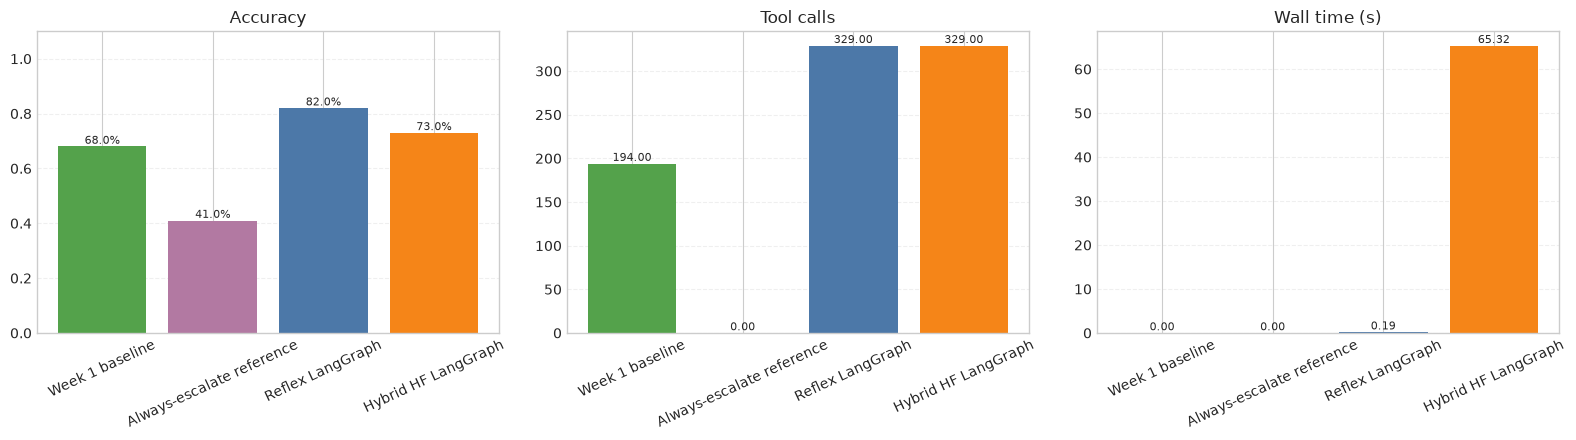

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
metric_titles = {'accuracy': 'Accuracy', 'tool_calls': 'Tool calls', 'wall_time_s': 'Wall time (s)'}
colors = {'week1': '#54a24b', 'reference': '#b279a2', 'reflex': '#4c78a8', 'hybrid': '#f58518'}

for ax, metric in zip(axes, ['accuracy', 'tool_calls', 'wall_time_s']):
    values = comparison_df[metric].values
    labels = comparison_df['option'].values
    bar_colors = [colors[k] for k in comparison_df['key']]
    ax.bar(labels, values, color=bar_colors)
    ax.set_title(metric_titles[metric])
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    if metric == 'accuracy':
        ax.set_ylim(0, 1.1)
    for bar, value in zip(ax.patches, values):
        label = f'{value:.1%}' if metric == 'accuracy' else f'{value:.2f}'
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), label, ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

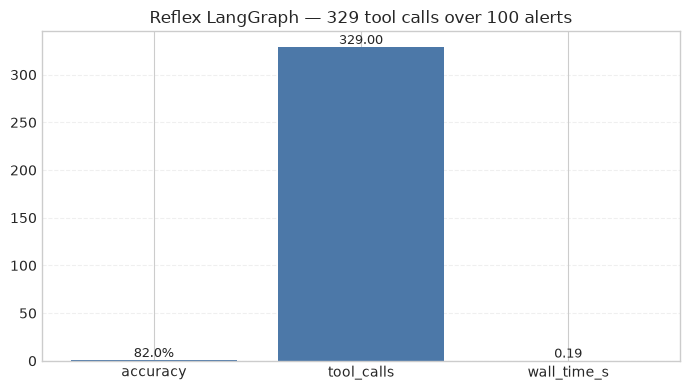

In [12]:
# Dedicated Reflex chart, sourced only from reflex_metrics.
fig, ax = plt.subplots(figsize=(7, 4))
reflex_bars = pd.DataFrame([
    {'metric': 'accuracy', 'value': reflex_metrics['accuracy']},
    {'metric': 'tool_calls', 'value': reflex_metrics['tool_calls']},
    {'metric': 'wall_time_s', 'value': reflex_metrics['wall_time_s']},
])
ax.bar(reflex_bars['metric'], reflex_bars['value'], color='#4c78a8')
ax.set_title(f"Reflex LangGraph — {reflex_metrics['tool_calls']} tool calls over {N_ALERTS} alerts")
ax.grid(axis='y', linestyle='--', alpha=0.3)
for bar, value, metric in zip(ax.patches, reflex_bars['value'], reflex_bars['metric']):
    label = f'{value:.1%}' if metric == 'accuracy' else f'{value:.2f}'
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), label, ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

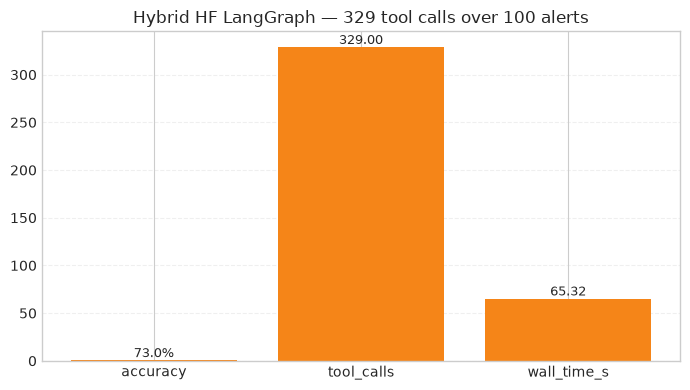

In [13]:
# Dedicated Hybrid chart, sourced only from hybrid_metrics.
fig, ax = plt.subplots(figsize=(7, 4))
hybrid_bars = pd.DataFrame([
    {'metric': 'accuracy', 'value': hybrid_metrics['accuracy']},
    {'metric': 'tool_calls', 'value': hybrid_metrics['tool_calls']},
    {'metric': 'wall_time_s', 'value': hybrid_metrics['wall_time_s']},
])
ax.bar(hybrid_bars['metric'], hybrid_bars['value'], color='#f58518')
ax.set_title(f"Hybrid HF LangGraph — {hybrid_metrics['tool_calls']} tool calls over {N_ALERTS} alerts")
ax.grid(axis='y', linestyle='--', alpha=0.3)
for bar, value, metric in zip(ax.patches, hybrid_bars['value'], hybrid_bars['metric']):
    label = f'{value:.1%}' if metric == 'accuracy' else f'{value:.2f}'
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), label, ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 10. Export results tables, plots, and reproducible artifacts

Write the comparison table and per-option run metadata to disk so the experiment can be reviewed or reproduced without rerunning the notebook.

In [14]:
out_dir = './assignment2_v2_artifacts'
os.makedirs(out_dir, exist_ok=True)

comparison_df.drop(columns=['tool_calls_by_name']).to_csv(os.path.join(out_dir, 'comparison_metrics.csv'), index=False)

with open(os.path.join(out_dir, 'option_runs.json'), 'w') as f:
    json.dump({
        key: {
            'tool_calls': val['tool_calls'],
            'tool_calls_by_name': val['tool_calls_by_name'],
            'wall_time_s': val['wall_time_s'],
            'decisions': val['decisions'],
        }
        for key, val in option_runs.items()
    }, f, indent=2, default=str)

with open(os.path.join(out_dir, 'config.json'), 'w') as f:
    json.dump({
        'seed': SEED,
        'n_alerts': N_ALERTS,
        'hf_model': HF_MODEL,
        'hf_token_set': bool(HF_TOKEN),
        'options': [opt.__dict__ for opt in OPTIONS],
    }, f, indent=2)

print(f'Artifacts exported to: {out_dir}')
print(comparison_df[['option', 'accuracy', 'cost_per_alert', 'tool_calls', 'wall_time_s']])

Artifacts exported to: ./assignment2_v2_artifacts
                      option  accuracy  cost_per_alert  tool_calls  \
0            Week 1 baseline      0.68           77.15         194   
1  Always-escalate reference      0.41           61.25           0   
2           Reflex LangGraph      0.82           38.65         329   
3        Hybrid HF LangGraph      0.73           63.40         329   

   wall_time_s  
0     0.000393  
1     0.000000  
2     0.191967  
3    65.321326  


## 11. What I would ship

The recommendation below is computed directly from `comparison_df`, not hardcoded, so it stays correct if the alerts, seed, or backend change.
Recommendation: ship Reflex LangGraph. It sweeps all three axes — 82.0% accuracy vs. 73.0%, $38.65/alert vs. $63.40, and 0.192s vs. 65.321s wall time — so the notebook now explicitly states that the extra HF API round-trip isn't justified given these results.

In [15]:
graph_df = comparison_df[comparison_df['key'].isin(['reflex', 'hybrid'])].set_index('key')
reflex_r, hybrid_r = graph_df.loc['reflex'], graph_df.loc['hybrid']

wins = {
    'accuracy': 'reflex' if reflex_r['accuracy'] >= hybrid_r['accuracy'] else 'hybrid',
    'cost_per_alert': 'reflex' if reflex_r['cost_per_alert'] <= hybrid_r['cost_per_alert'] else 'hybrid',
    'wall_time_s': 'reflex' if reflex_r['wall_time_s'] <= hybrid_r['wall_time_s'] else 'hybrid',
}
print('Per-metric winner (reflex vs hybrid):', wins)

reflex_sweep = all(w == 'reflex' for w in wins.values())
recommendation = 'Reflex LangGraph' if reflex_sweep else 'Hybrid HF LangGraph'

print(f"\nRecommendation: ship {recommendation}.")
print(
    f"Reflex  -> accuracy {reflex_r['accuracy']:.1%}, cost ${reflex_r['cost_per_alert']:.2f}/alert, "
    f"wall time {reflex_r['wall_time_s']:.3f}s for {N_ALERTS} alerts."
)
print(
    f"Hybrid  -> accuracy {hybrid_r['accuracy']:.1%}, cost ${hybrid_r['cost_per_alert']:.2f}/alert, "
    f"wall time {hybrid_r['wall_time_s']:.3f}s for {N_ALERTS} alerts."
)

if reflex_sweep:
    print(
        "\nReflex sweeps all three axes: it is more accurate, cheaper per alert, and faster than the "
        "HF-backed hybrid graph on this dataset. The extra network round-trip to the Hugging Face API "
        "buys no measurable benefit here, so the added latency and dependency on an external service are "
        "not justified. Ship the reflex graph and keep the hybrid path available only for future cases "
        "where log text is too ambiguous for keyword rules to resolve."
    )
else:
    print(
        "\nHybrid did not lose on every axis this run, so the tradeoff is closer than a pure reflex "
        "recommendation would suggest. Re-check the per-metric winners above before deciding."
    )

Per-metric winner (reflex vs hybrid): {'accuracy': 'reflex', 'cost_per_alert': 'reflex', 'wall_time_s': 'reflex'}

Recommendation: ship Reflex LangGraph.
Reflex  -> accuracy 82.0%, cost $38.65/alert, wall time 0.192s for 100 alerts.
Hybrid  -> accuracy 73.0%, cost $63.40/alert, wall time 65.321s for 100 alerts.

Reflex sweeps all three axes: it is more accurate, cheaper per alert, and faster than the HF-backed hybrid graph on this dataset. The extra network round-trip to the Hugging Face API buys no measurable benefit here, so the added latency and dependency on an external service are not justified. Ship the reflex graph and keep the hybrid path available only for future cases where log text is too ambiguous for keyword rules to resolve.
